In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sympy.physics.quantum.dagger import Dagger
import math
import random
import cmath
from sympy import I, Matrix, symbols
from sympy.physics.quantum import TensorProduct
import pandas as pd
from IPython.display import clear_output
#import Hamiltonian
#import build_H

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
one = np.array([[1., 0.],[0.,1.]])
pauli_1 = np.array([[0.,1.],[1.,0.]])
pauli_2 = np.array([[0., 0-1j],[0 +1j, 0.]])
pauli_3 = np.array([[1.,0.],[0., -1.]])
plus = (1/2 * (pauli_1 + 1.j * pauli_2)).real
minus = (1/2 * (pauli_1 - 1.j * pauli_2)).real

In [4]:
number_of_qubits = 14
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)

def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)
#basis[basis == 0] = -1

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])


In [5]:
#Hamiltonian
#number_of_qubits = 2
#m = 0.1

def Get_H(m, number_of_qubits):
    res_XY = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_mass = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_iter = torch.zeros(2**number_of_qubits, 2**number_of_qubits)


    # XY term
    first = one
    for i in range(1,number_of_qubits):
        #print(i)
        first = one
        second = one
        for j in range(1, number_of_qubits -i-1):
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        if i != number_of_qubits - 1 :
            first = TensorProduct(minus, first)
            first = TensorProduct(plus, first)
            second = TensorProduct(plus, second)
            second = TensorProduct(minus, second)
        else:
            first = TensorProduct(plus, minus)
            second = TensorProduct(minus, plus)
        for j in range(1,i):
            #print("uu")
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        #print(c.size())
        res_XY += torch.from_numpy(first + second)

    #print(res_XY)

    # mass term
    for i in range(1, number_of_qubits + 1):
        mass = one
        for j in range(1, number_of_qubits - i):
            mass = TensorProduct(one, mass)
        if i == number_of_qubits:
            mass = pauli_3
        else:
            mass = TensorProduct(pauli_3, mass)
        for j in range(1, i):
            mass = TensorProduct(one, mass)
    
        res_mass += (-1)**i * (torch.from_numpy(mass))
    
       
    #print(res_mass)

    # iteraction term
    for i in range(1,number_of_qubits ):
        res_ite = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        res_ones = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        for j in range(1, i + 1):
        
            ite = one
        
            for k in range(1, number_of_qubits - j):
                ite = TensorProduct(one, ite)
            if j == number_of_qubits:
                ite = pauli_3
            else:
                ite = TensorProduct(pauli_3, ite)
            for k in range(1, j):
                ite = TensorProduct(one, ite)
            res_ite += (torch.from_numpy(ite)) 
            ones = one
        
            for k in range(1,number_of_qubits):
                ones = TensorProduct(one, ones)
            res_ones += (-1)**j*(torch.from_numpy(ones))
        res_iter += torch.matmul(res_ones + res_ite, res_ones + res_ite)   
    
    
    return 1/4*res_iter + res_XY + m/2*res_mass 
#H = Get_H(0.2,2)
#I = torch.zeros(2**number_of_qubits,2**number_of_qubits)
#for i in range(2**number_of_qubits):
#    I[i][i] = 1.579100
#H = H +I
#print(H)

In [6]:
def matrix_element_iter_new(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    C = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1).to(device)
    
    coef_first = number_of_qubits - number_of_qubits % 2
    coef = torch.zeros(number_of_qubits ).to(device)
    
    for i in range(number_of_qubits -1):
        coef[i] = -coef_first
        if i%2 == 0 : 
            coef_first = coef_first-2       

    C[j,j] = -(batch_new[j]*coef).sum(dim = 1)
    coef_2 = (torch.arange(number_of_qubits -2, 0, -1)*2).to(device)
    
    for i in range(0,number_of_qubits-1):
        s = torch.zeros(batch_size).to(device)
        for m in range(i+1, number_of_qubits-1):
            #print(m, coef_2[m-1])
            s += coef_2[m - 1]*batch_new[:,m]
            #print(s)
        #print(s)    
        C[j,j] += batch_new[j,i]*s[j]
       
    One = torch.eye(batch_size, batch_size).to(device)
    I = torch.tensor([range(0,number_of_qubits)]).sum()
    I += math.floor(number_of_qubits/2)
    One *= I    
    return (C + One)/4
                
            
def matrix_element_xy(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    
    place = torch.zeros(number_of_qubits -1,2)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][0]= i
        place[i][1] = i+1
    outt = torch.arange(batch_size)
    for i in outt:
        for j in outt:
            true = (torch.nonzero(batch_new[i] != batch_new[j])).reshape(-1)
            if (true.shape[0] == 2) and ((true == place).prod(dim = 1).sum()):
                C[i,j] = 1 -batch_new[i,true[0]]*batch_new[i,true[1]]
    return C/2

def matrix_element_m(batch):

    batch_new = torch.clone(batch)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    
    t = torch.arange(0,number_of_qubits,1).to(device)
    
    batch_new[:,t] *= (-1)**(t+1)
    
    M = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1)
    M[j,j] = -batch_new.sum(dim = 1)
        #N+= M
    return m/2*M

def matrix_element_xy_new_7(batch):
    batch_new = torch.clone(batch)
    #print(batch_new.device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    res = batch_new.unsqueeze(1) != batch_new
    
    place = torch.zeros(number_of_qubits -1,number_of_qubits).to(device)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][i]= 1
        place[i][i+1] = 1
        true = torch.nonzero((res == place[i]).prod(dim = 2)==1)
        ress = batch_new[true[:,0],i]*batch_new[true[:,0],i+1]
        C[true[:,0], true[:,1]] = 1 - ress
    return C/2

def matrix(batch):               
    return  matrix_element_iter_new(batch) + matrix_element_xy_new_7(batch) + matrix_element_m(batch)

In [7]:
m = 0.1
#H = Get_H(m, number_of_qubits)
#print(H)
torch.set_printoptions(precision=5)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[0]
print(c,m)
#print(net.loss(net(basis)/net(basis).norm()), 'loss через H')
#print(torch.sort(eig_values))

NameError: ignored

In [8]:
def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)

In [9]:
sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch
#print(sub_batch)
print(good_batch.sum(dim = 1))

7
torch.Size([3432]) torch.Size([3432])
tensor([7., 7., 7.,  ..., 7., 7., 7.])


In [10]:
def make_good_batch(size):
    i = torch.randint(sub_batch.shape[0], (1,))
    #print(i)
    batch = sub_batch[i]
    #print(batch)
    i = torch.randint(sub_batch.shape[0], (size - 1,))
    #print(i)
    for m in range(i.shape[0] , 0, -1):
        #print(sub_batch[i[m-1] + 1].view(1, number_of_qubits))
        batch = torch.cat((batch, sub_batch[i[m-1],:].view(1, number_of_qubits)), axis = 0)
    return batch

In [11]:
print(make_good_batch(11).sum(dim = 1))

tensor([7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7.])


In [12]:
class Net(nn.Module):
    
    lr = 0.001
    
    
    N_epochs = 2000
    
    def __init__(self):
        super(Net,self).__init__()
        self.Linear0 = nn.Linear(number_of_qubits, 100)
        self.Linear1 = nn.Linear(100, 100)
        self.Linear2 = nn.Linear(100, 100)
        self.Linear3 = nn.Linear(100, 100)
        self.Linear4 = nn.Linear(100, 1)
        
        self.relu = nn.ReLU()
        self.bn0 = nn.BatchNorm1d(100)
        self.tanh = nn.Tanh()
    def forward(self,x):
        x = self.Linear0(x)
        x = self.relu(x)
        x = self.bn0(x)
        x = self.Linear1(x)
        x = self.relu(x)
        x = self.bn0(x)
        x = self.Linear2(x)
        x = self.relu(x)
        x = self.bn0(x)
        x = self.Linear3(x)
        x = self.relu(x)
        x = self.bn0(x)
        x = self.Linear4(x)
        return x
    
    
    def sample2(self,batch,i):
        accepted = 0
        #count = 0
        for k in range(0,5):
            batch_new = torch.clone(batch)
            dims = torch.arange(batch_size)
            ind = torch.randint(number_of_qubits,(batch_size,))
            batch_new[dims, ind] = 1 - batch_new[dims, ind]

            amplitude = new(batch)
            amplitude_new = new(batch_new)
            #A = torch.reshape((amplitude_new/amplitude)**2,(batch_size,))
            #u = torch.rand((batch_size))
            A = torch.reshape(torch.log(amplitude_new**2 + 1) -  torch.log(amplitude**2 + 1),(batch_size,))
            u = torch.log(torch.rand((batch_size)))
            batch[u < A,:] = batch_new[u < A,:]
            
        return batch
    
    
    def sample(self,batch,i):
        accepted = 0
        #count = 0
        for k in range(0,2):
            batch_new = torch.clone(batch).to(device)
            dims = torch.arange(batch_size)
            
            zeros = (batch == 0).nonzero()[:,1].view(batch_size,number_of_qubits - sum_spin ).to(device)
            ones = (batch == 1).nonzero()[:,1].view(batch_size,number_of_qubits - sum_spin ).to(device)
            ind = torch.randint(number_of_qubits - sum_spin,(batch_size,)).to(device)
            ind2 = torch.randint(number_of_qubits - sum_spin,(batch_size,)).to(device)
            i = torch.arange(0,batch_size,1).to(device)
            ind = zeros[i, ind].to(device)
            ind2 = ones[i, ind2]  .to(device)
            #print((ind == ind2).nonzero())
            
            batch_new[dims, ind] = 1 - batch_new[dims, ind]
            batch_new[dims, ind2] = 1 - batch_new[dims, ind2]
            #batch_new = torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)

            amplitude = new(batch).to(device)
            amplitude_new = new(batch_new).to(device)
            
            #a = 2**torch.arange(number_of_qubits -1, -1,-1)
            #out = batch*a 
            #out = distr((out.sum(dim = 1))).view(out.shape[0], 1)
        
            #outt = batch_new*a 
            #outt = distr((outt.sum(dim = 1))).view(outt.shape[0], 1)
            
            #print(torch.log((amplitude_new**2 + 1)*out).shape)
            A = torch.reshape(torch.log(amplitude_new**2 + 1) -  torch.log(amplitude**2 + 1),(batch_size,)).to(device)
            #A = torch.reshape(torch.log(amplitude_new**2 * out + 1) -  torch.log(amplitude**2 * outt + 1),(batch_size,))
            u = torch.log(torch.rand((batch_size))).to(device)
            batch[u < A,:] = batch_new[u < A,:]
            #print((u < A).nonzero().shape[0])
            #print(batch.sum(dim = 1))
            #out, num= torch.unique(batch, return_counts = True,dim = 0)
            #print(out.shape[0])
        return batch
    
    def loss2(self,batch):
        out, num= torch.unique(batch, return_counts = True,dim = 0)
        psi = new(out)
        epsilon = 0.00001
        psi = psi/(psi.norm())
        
        #a = 2**torch.arange(number_of_qubits -1, -1,-1)
        #b = out*a 
        #b = (b.sum(dim = 1)).view(out.shape[0], 1)
        #print(b)
        #k = (b == 341).nonzero()[:,1]
        #print(k)
        
        #print(psi.shape)
        #print(psi[k])
        #psi[k] = 0.29
        #CP = CP_conj(out)
        #for i in range(CP.shape[0]):
        #    b = (out == CP[i,:]).prod(1).nonzero()
        #    psi[b] = psi[i]
            
        psi = psi/(psi.norm()).to(device)
        M = matrix(out).to(device)
        E = torch.matmul(torch.transpose(psi, 0, 1), torch.matmul(M, psi))
        return E
    
    def optimize(self,inp):
        optimizer = torch.optim.Adam(self.parameters(), lr = self.lr, betas=(0.9, 0.999))###
        #optimizer = torch.optim.SGD(self.parameters(), self.lr, momentum= 0.5) 
        distance = []
        count = 0
        #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2000,10000], gamma=0.1)
        for i in tqdm(range(self.N_epochs)): #tqdm показывет процесс выполенения в процентах
            optimizer.zero_grad()
            
            #inp = self.sample(inp,i)
            loss_curr = self.loss2(inp)
        
            if i == self.N_epochs - 1:
                print(loss_curr)
                
            loss_curr.backward()
            optimizer.step() # parameter update
            distance.append(loss_curr.view(1).detach().cpu().numpy())# To stop a tensor from tracking history, you can call .detach() 
            count += 1
            if count == 100:
                clear_output()
                plt.plot(distance)
                plt.show()
                print(loss_curr)
                count = 0
        return distance

In [ ]:
def CP_conj(batch):
    add = torch.clone(batch)
    CP_batch = torch.clone(batch)
    i = torch.arange(0,number_of_qubits/2,1).type(torch.LongTensor)
    j = torch.arange(number_of_qubits-1, number_of_qubits/2-1, -1).type(torch.LongTensor)
    CP_batch[:,i] = CP_batch[:,j]
    CP_batch[:,j] = add[:,i]
    add = torch.clone(CP_batch)

    CP_batch[add == 0] = 1
    CP_batch[add == 1] = 0
    return CP_batch

In [13]:
number_of_qubits = 14
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)

def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)
#basis[basis == 0] = -1
sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch
#print(sub_batch)
#print(good_batch.sum(dim = 1))

def make_good_batch(size):
    i = torch.randint(sub_batch.shape[0], (1,))
    #print(i)
    batch = sub_batch[i]
    #print(batch)
    i = torch.randint(sub_batch.shape[0], (size - 1,))
    #print(i)
    for m in range(i.shape[0] , 0, -1):
        #print(sub_batch[i[m-1] + 1].view(1, number_of_qubits))
        batch = torch.cat((batch, sub_batch[i[m-1],:].view(1, number_of_qubits)), axis = 0)
    return batch

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])
7
torch.Size([3432]) torch.Size([3432])


In [14]:
def permutations():
  main = torch.ones(nq)
  i = torch.arange(0,nq,2)
  main[i] = 0
  #print(main)
  a = 2**torch.arange(nq -1, -1,-1)
  num_main = (main*a).sum()
  #print(num_main)
  #new = torch.zeros(nq,nq-1)
  pm = torch.clone(main.reshape(1,nq).expand(nq-1,nq))
  for i in range(nq - 1):
    pm[i,i] = 1 - main[i]
    pm[i,i+1] = 1 - main[i+1]
  i = torch.arange(nq-1)
  res = torch.zeros(nq - 1, nq)
  ress = torch.zeros(nq - 1)
  res[i] = pm[i]*a 
  ress[i] = res[i].sum(dim = 1)
  batch = torch.cat((main.view(1,nq),pm), 0)
  ress = torch.cat((num_main.view(1),ress),0)
  t = ress.sort()
  i = torch.arange(nq)
  batch2 = torch.zeros(batch.shape[0], batch.shape[1])
  batch2[i,:] =  batch[t.indices[i],:]
  return batch2, t.values.long()

In [53]:
nq = 14
number_of_qubits = nq
batch, nums = permutations()

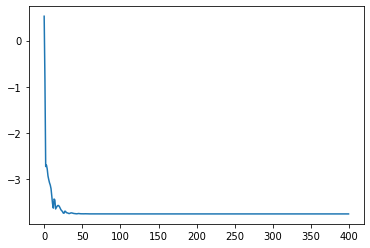






 20%|██        | 408/2000 [00:05<00:19, 80.00it/s]

tensor([[-3.75513]], device='cuda:0', grad_fn=<MmBackward>)


KeyboardInterrupt: ignored

In [54]:
new = Net()
new.to(device)
m = 0.1
batch = batch.to(device)
batch_size = batch.shape[0]
dist = new.optimize(batch)
plt.plot(dist[1:])

tensor([[-0.17930],
        [-0.17930],
        [-0.17930],
        [-0.17930],
        [-0.17930],
        [-0.17930],
        [ 0.76294],
        [-0.17930],
        [-0.17930],
        [-0.17930],
        [-0.17930],
        [-0.17930],
        [-0.17930],
        [-0.17930]])
tensor([-5.43422])


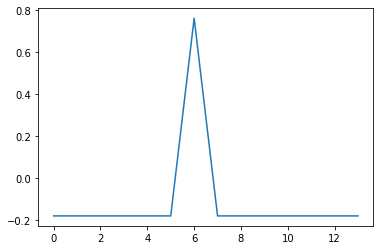

In [59]:
T = new(batch.to(device)).detach().cpu()
T = T/T.norm()
T = T.view(T.shape[0], 1)
print(T)
print(T.sum()/T[6]/0.235*0.427 - 1 - 0.1/2*14)
plt.plot(T)

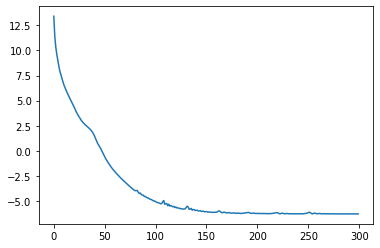




 15%|█▌        | 300/2000 [01:46<12:04,  2.35it/s]

tensor([[-6.28451]], device='cuda:0', grad_fn=<MmBackward>)





 15%|█▌        | 301/2000 [01:46<11:25,  2.48it/s]


 15%|█▌        | 302/2000 [01:47<10:59,  2.58it/s]


 15%|█▌        | 303/2000 [01:47<10:40,  2.65it/s]


 15%|█▌        | 304/2000 [01:47<10:26,  2.71it/s]


 15%|█▌        | 305/2000 [01:48<10:17,  2.75it/s]


 15%|█▌        | 306/2000 [01:48<10:11,  2.77it/s]


 15%|█▌        | 307/2000 [01:48<10:07,  2.79it/s]


 15%|█▌        | 308/2000 [01:49<10:04,  2.80it/s]


 15%|█▌        | 309/2000 [01:49<10:02,  2.81it/s]


 16%|█▌        | 310/2000 [01:50<10:00,  2.81it/s]


 16%|█▌        | 311/2000 [01:50<09:58,  2.82it/s]


 16%|█▌        | 312/2000 [01:50<09:57,  2.82it/s]


 16%|█▌        | 313/2000 [01:51<09:56,  2.83it/s]


 16%|█▌        | 314/2000 [01:51<09:57,  2.82it/s]


 16%|█▌        | 315/2000 [01:51<09:55,  2.83it/s]


 16%|█▌        | 316/2000 [01:52<09:53,  2.84it/s]


 16%|█▌        | 317/2000 [01:52<09:53,  2.83it/s]


 16%|█▌        | 318/2000 [01:52<09:52,  2.84it/s]


 16%|█▌        | 319/2000 [01:53<09:49,  2.

KeyboardInterrupt: ignored

In [49]:
new = Net()
new.to(device)
m = 0.1

pick = math.ceil((2**number_of_qubits*0.33))
batch_size = good_batch.shape[0]
batch = good_batch.to(device)
#batch_size = 10000
#batch = make_good_batch(batch_size).to(device)
#print(batch.sum(1))


dist = new.optimize(batch)
plt.plot(dist[1:])

#print('exact solution ={}'.format(c))

torch.Size([16384, 1])
torch.Size([3432, 1])
tensor([[ 616,    0],
        [ 952,    0],
        [1043,    0],
        [1068,    0],
        [1075,    0],
        [1077,    0],
        [1078,    0],
        [1079,    0],
        [1080,    0],
        [1084,    0],
        [1098,    0],
        [1148,    0],
        [1330,    0],
        [2002,    0]])
tensor([-0.42721])


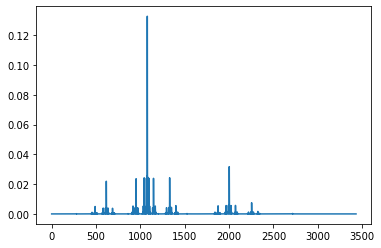

In [50]:
torch.set_printoptions(precision=5)
#eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
#eig_vector = torch.eig(H, eigenvectors = True)[1]
#c = eig_values.min()
#m = torch.min(eig_values,0)[1]
#R = eig_vector[:,m].reshape(2**number_of_qubits)
T = new(good_batch.to(device)).detach().cpu()

T = T/T.norm()
T = T.view(T.shape[0], 1)
my_way = torch.zeros(2**number_of_qubits, 1)
print(my_way.shape)
print(T.shape)
plt.plot(T**2)
print((T**2 > 0.01).nonzero())
print(T[1043]/T[1078])
#my_way[good_vectors, :] = T[i, :]
#print(my_way)

tensor(0.)
torch.Size([6435, 1]) torch.Size([65536, 1])
tensor(1.00001) tensor(0.00185)


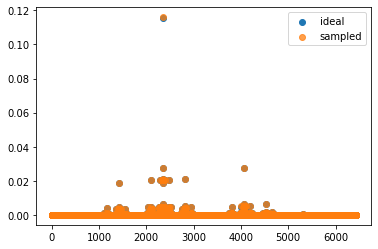

In [ ]:
import matplotlib.colors as mcolors
a = torch.tensor(np.load('number_of_qubits_15.npy')).float()
print(my_way.norm())
x = np.arange(0,2**number_of_qubits)
x = torch.arange(good_batch.shape[0])
y = np.random.randint(1, 20, size = 2**number_of_qubits)
#for i in range(0,2**number_of_qubits):
#    y[i] = a[i]

z = torch.zeros(2**number_of_qubits)
#for i in range(0,2**number_of_qubits):
#    z[i] = times[i]
z = T**2
#z = my_way**2
print(z.shape, aa.shape)
print(z.sum(), a.sum())
fig, ax = plt.subplots()
ax.scatter(x, a**2, alpha = 1, label='ideal')
ax.scatter(x, z, alpha = 0.75, label='sampled')
#ax.set_xticks(x)
ax.legend()
plt.show()

In [ ]:
my_way = my_way.view(my_way.shape[0])
#print(torch.dot(T,R)**2)
#print(torch.dot(my_way,R)**2)
#print(torch.dot(T,my_way)**2)

NameError: ignored

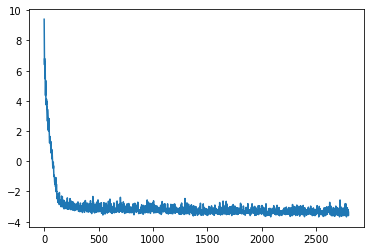

  6%|▌         | 2803/50000 [02:57<1:07:52, 11.59it/s]

tensor([[-3.37353]], grad_fn=<MmBackward>)


  6%|▌         | 2820/50000 [02:58<49:51, 15.77it/s]  


KeyboardInterrupt: 

In [ ]:
new = Net()
#мой способ
#k = 3
m = 0.1
batch_size = 2**number_of_qubits
batch_size = 200
batch = make_batch(batch_size)
print(basis)
#batch = torch.clone(basis)

dist = new.optimize(batch)
plt.plot(dist[1:])
#print(net(basis)/net(basis).norm())

print(net.loss(net(basis)/net(basis).norm()))

In [ ]:
torch.set_printoptions(precision=5)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[1]
R = eig_vector[:,m].reshape(2**number_of_qubits)
#min_vector = eig_vector[:,m].reshape(1,2**number_of_qubits)
T = new(basis).detach().cpu()
T = (T/T.norm()).view(T.shape[0])
print(T.shape)
#T[basis == 0] = torch.sqrt(torch.abs(1 + 0.000001 - T[basis == 0]**2))
#T = T.prod(dim = 1).reshape(2**number_of_qubits)
print(torch.dot(T,R)**2)
#T = T/T.norm()

#print(T)
print(torch.matmul(torch.transpose(T.view(basis.shape[0],1), 0, 1), torch.matmul(H, T)))

NameError: ignored

In [ ]:
import matplotlib.colors as mcolors
a = R**2
print(my_way.norm())
x = np.arange(0,2**number_of_qubits)
y = np.random.randint(1, 20, size = 2**number_of_qubits)
#for i in range(0,2**number_of_qubits):
#    y[i] = a[i]

z = torch.zeros(2**number_of_qubits)
#for i in range(0,2**number_of_qubits):
#    z[i] = times[i]
z = T**2
#z = my_way**2
print(z.sum(), a.sum())
fig, ax = plt.subplots()
ax.scatter(x, a, alpha = 1, label='ideal')
ax.scatter(x, z, alpha = 0.75, label='sampled')
#ax.set_xticks(x)
ax.legend()
plt.show()

NameError: ignored

tensor(1.00000)


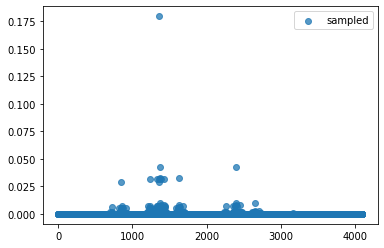

In [ ]:
import matplotlib.colors as mcolors
#a = R**2
print(my_way.norm())
x = np.arange(0,2**number_of_qubits)
y = np.random.randint(1, 20, size = 2**number_of_qubits)
#for i in range(0,2**number_of_qubits):
#    y[i] = a[i]

z = torch.zeros(2**number_of_qubits)
#for i in range(0,2**number_of_qubits):
#    z[i] = times[i]
#z = T**2
z = my_way**2
#print(z.sum(), a.sum())
fig, ax = plt.subplots()

#ax.scatter(x, a, alpha = 1, label='ideal')
ax.scatter(x, z, alpha = 0.75, label='sampled')
#ax.set_xticks(x)
ax.legend()
plt.show()

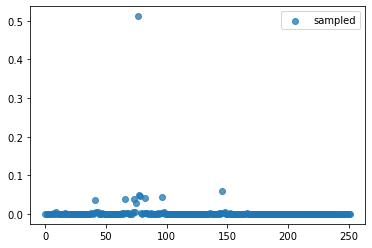

tensor([[146,   0]])


In [ ]:
fig, ax = plt.subplots()
x = torch.arange(0,T.shape[0],1)
#ax.scatter(x, a, alpha = 1, label='ideal')
ax.scatter(x, T**2, alpha = 0.75, label='sampled')
#ax.set_xticks(x)
ax.legend()
plt.show()
print((T ==T.max()).nonzero())

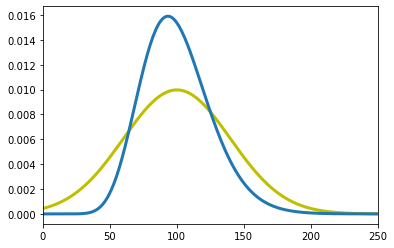

tensor([[0.00044, 0.00044, 0.00044],
        [0.00044, 0.00044, 0.00044],
        [0.00044, 0.00044, 0.00044]])


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mu, sigma = 100, 40
beta, alpha = 0.15,15
s = np.random.normal(mu, sigma, 1000)
#print(s)
# Create the bins and histogram
#count, bins, ignored = plt.hist(s, 200, normed=True)
bins = torch.arange(0,250,1).float()
#print(bins)

# Plot the distribution curve
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) *
    np.exp( - (bins - mu)**2 / (2 * sigma**2) ),       linewidth=3, color='y')
plt.plot(bins, beta**alpha * bins**(alpha - 1) * torch.exp(- beta*bins)/math.gamma(alpha),  linewidth=3 )
plt.xlim(0, 250)
plt.show()

def distr(bins):
     return beta**alpha * bins**(alpha - 1) * torch.exp(- beta*bins)/math.gamma(alpha)
    
def distr2(bins):
     return 1/(sigma * np.sqrt(2 * np.pi)) * torch.exp(- (bins - mu)**2 /(2 * sigma**2))
    
print(distr2(torch.ones(3,3)*200))

In [ ]:
ax = sns.distplot(data_gamma,
                  kde=True,
                  bins=100,
                  color='skyblue',
                  hist_kws={"linewidth": 15,'alpha':1})
ax.set(xlabel='Gamma Distribution', ylabel='Frequency')

NameError: name 'sns' is not defined

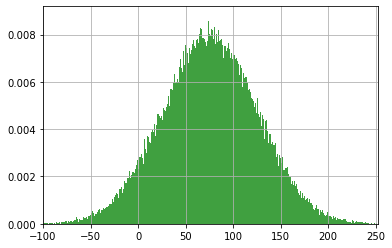

In [ ]:
np.random.seed(19680801)

mu, sigma = 76, 50
x = mu - sigma * np.random.randn(100000)
# the histogram of the data
n, bins, patches = plt.hist(x, 500, density=True, facecolor='g', alpha=0.75)

plt.xlim(-100, 252)
plt.grid(True)
plt.show()

In [ ]:
from scipy.stats import poisson
print(poisson.stats(5,4))
print(poisson.rvs(mu=4, size=10000))

(array(9.), array(5.))
[4 6 5 ... 3 3 4]


[190 198 190 ... 243 211 199]


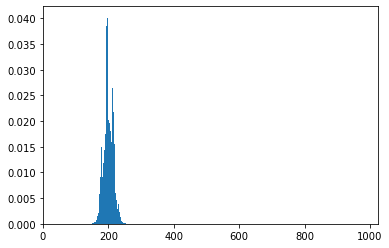

In [ ]:
s = np.random.poisson(200, 100000)
print(s)
count, bins, ignored = plt.hist(s, 100, density=True)
plt.xlim(0, basis.shape[0])
plt.show()

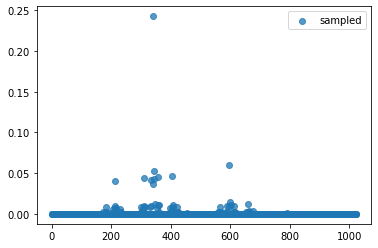

In [ ]:
fig, ax = plt.subplots()
x = torch.arange(0,my_way.shape[0],1)
#ax.scatter(x, a, alpha = 1, label='ideal')
ax.scatter(x, my_way**2, alpha = 0.75, label='sampled')
#ax.set_xticks(x)
ax.legend()
plt.show()

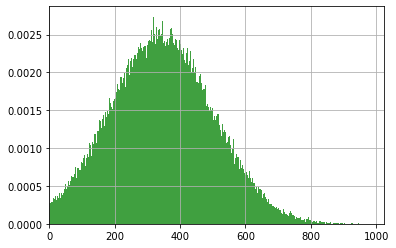

In [ ]:
np.random.seed(19680801)

mu, sigma = 341, 160
x = mu + sigma * np.random.randn(100000)
# the histogram of the data
n, bins, patches = plt.hist(x, 500, density=True, facecolor='g', alpha=0.75)

plt.xlim(0, 1024)
plt.grid(True)
plt.show()